# Assignment 1 - Optional part

## Part 1 - Improve the performance
In this section, we explore some techniques with the aim to maximize the performance of the 1-layer FCNN.
### Baseline
The baseline for this section will be the best performing model from the mandatory part, which has parameters
- batch_size = 100
- num_of_epochs = 40
- learning_rate = 0.001
- regularization_parameter = 0.1
and achieved test accuracy of **0.392**.

### a) using all available data for training

In [1]:

# Load all data batches
from utils import load_batch
import matplotlib.pyplot as plt
import numpy as np
from model import Model
from optimizer import Optimizer
from nodes import CrossEntropyLoss

X_test, Y_test, y_test = load_batch("test_batch")

X, Y, y = load_batch("data_batch_1")
print("Shape for data batch 1:")
print(X.shape, Y.shape, y.shape)
for i in range(2,6):
    X_temp, Y_temp, y_temp = load_batch(f"data_batch_{i}")
    X = np.concatenate((X, X_temp), axis=1)
    Y = np.concatenate((Y, Y_temp), axis=1)
    y = np.concatenate((y, y_temp))
print("Shape for combined data:")
print(X.shape, Y.shape, y.shape)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Shape for data batch 1:
(3072, 10000) (10, 10000) (10000,)
Shape for combined data:
(3072, 50000) (10, 50000) (50000,)


In [2]:
# split into training and validation sets
split = int(0.97 * X.shape[1])
X_train, Y_train, y_train = X[:, :split], Y[:, :split], y[:split]
X_val, Y_val, y_val = X[:, split:], Y[:, split:], y[split:]
print("Shape for training set:")
print(X_train.shape, Y_train.shape, y_train.shape)
print("Shape for validation set:")
print(X_val.shape, Y_val.shape, y_val.shape)

Shape for training set:
(3072, 48500) (10, 48500) (48500,)
Shape for validation set:
(3072, 1500) (10, 1500) (1500,)


In [3]:
# train with the default parameters
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.0)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=100, batch_size=100, print_every=10)

KeyboardInterrupt: 

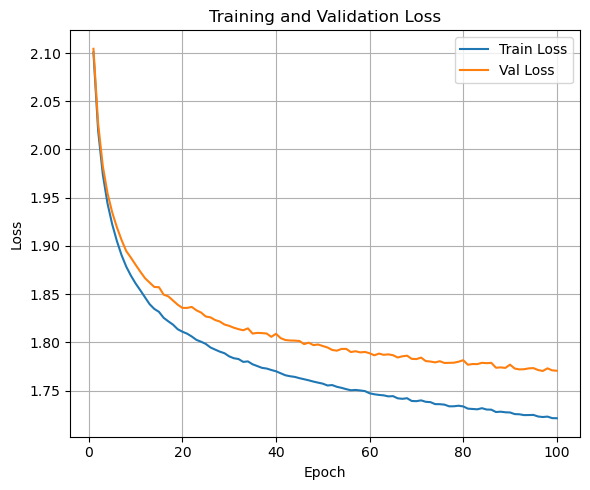

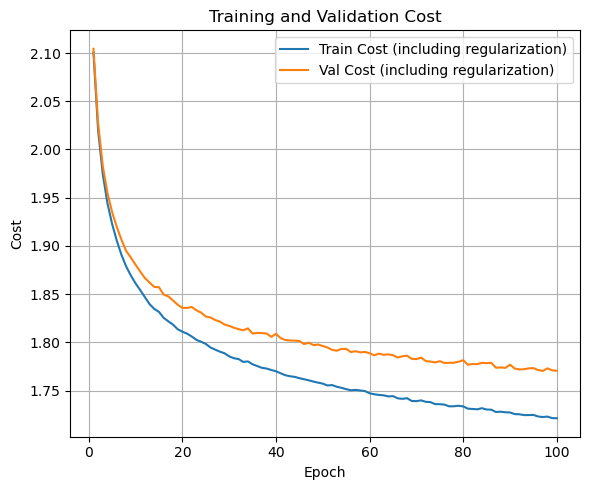

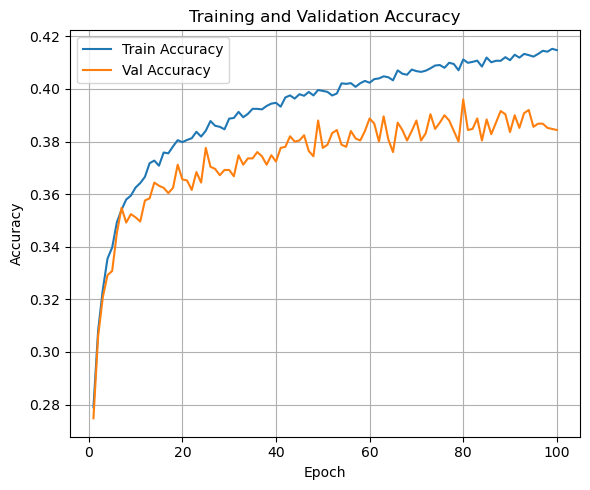

In [36]:
optimizer.plot_training_progress()

In [4]:
# test the model on the test set
X_test, Y_test, y_test = load_batch("test_batch")
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.3435


### Augmenting data by flipping images horizontally

In [3]:
xx = X_test[:,0]
aa = np.int32(np.arange(32)).reshape((32, 1))
bb = np.int32(np.arange(31, -1, -1)).reshape((32, 1))
vv = np.tile(32*aa, (1, 32))
ind_flip = vv.reshape((32*32, 1)) + np.tile(bb, (32, 1))
inds_flip = np.vstack((ind_flip, 1024+ind_flip))
inds_flip = np.vstack((inds_flip, 2048+ind_flip))
xx_flipped = xx[inds_flip.flatten()]

NameError: name 'X_test' is not defined

NameError: name 'xx' is not defined

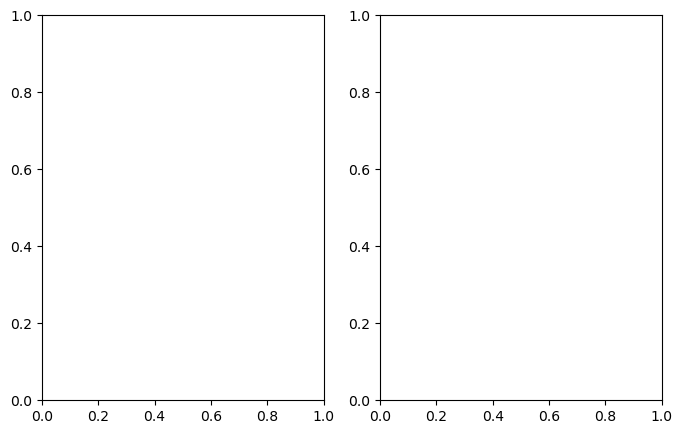

In [4]:
ni = 5
fig, axs = plt.subplots(1, 2, figsize=(8, 5))
xx = xx.reshape((32, 32, 3), order='F')
xx = np.transpose(xx, (1, 0, 2))
axs[0].imshow(xx)
axs[0].axis('off')
xx_flipped = xx_flipped.reshape((32, 32, 3), order='F')
xx_flipped = np.transpose(xx_flipped, (1, 0, 2))
axs[1].imshow(xx_flipped)
axs[1].axis('off')
plt.pause(0.1)

In [5]:
# test the horizontal flipping:
xx = X_train[:,:2]
print(xx.shape)
xx_flipped = optimizer.flip_vertically(xx)
for i in range(2):
    x = xx[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)
for i in range(2):
    x = xx_flipped[:, i]
    print(x.shape)
    x = x.reshape((32, 32, 3), order='F')
    x = np.transpose(x, (1, 0, 2))
    plt.imshow(x)
    plt.axis('off')
    plt.pause(0.1)

(3072, 2)


NameError: name 'optimizer' is not defined

In [3]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.005, reg=0.0, vertical_flip_prob=0.5)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=120, batch_size=100, print_every=10)

KeyboardInterrupt: 

In [13]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=20, batch_size=100, print_every=10)

Epoch 10/20 - Train Loss: 1.7210, Val Loss: 1.7584, Train Acc: 0.4127, Val Acc: 0.4033
Epoch 20/20 - Train Loss: 1.7168, Val Loss: 1.7542, Train Acc: 0.4143, Val Acc: 0.4053


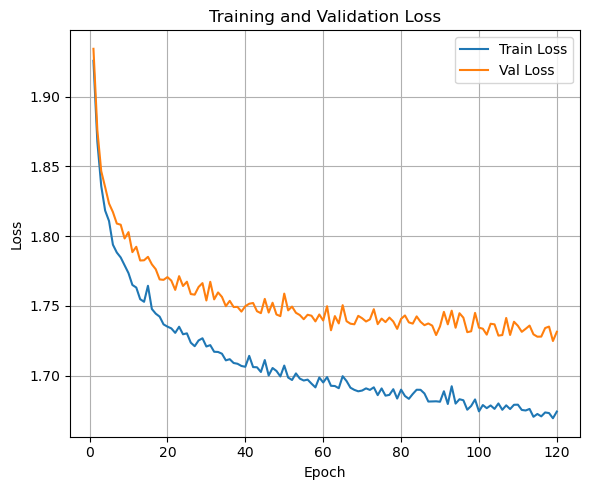

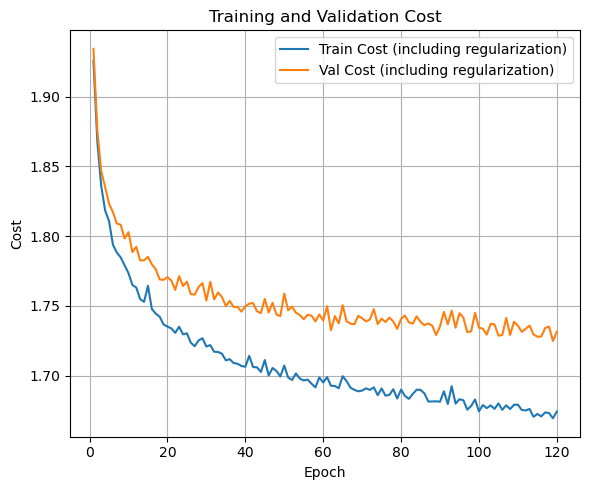

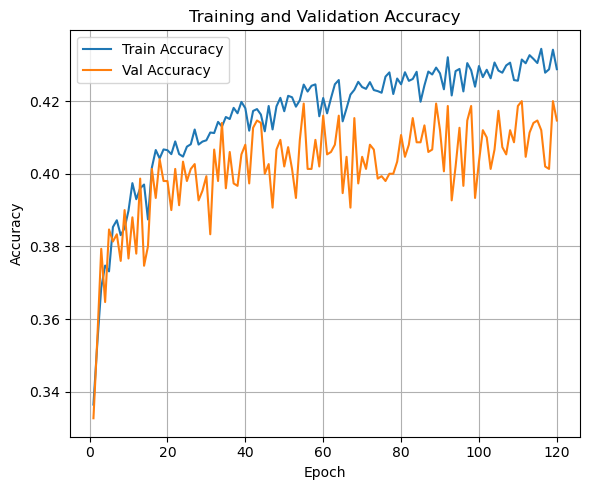

In [17]:
optimizer.plot_training_progress()

In [18]:
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.4123


### Grid search

In [3]:
lr_values = [0.001, 0.005, 0.01, 0.1]
reg_values = [0.0, 0.001, 0.01, 0.1]
batch_values = [20, 50, 100, 200]
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.01, reg=0.01, vertical_flip_prob=0.0)
optimizer.grid_search(X_train, y_train, X_val, y_val, lr_values, reg_values, batch_values)

Testing lr=0.001, reg=0.0, batch_size=20
Max validation accuracy 0.4187 at epoch 110
Testing lr=0.001, reg=0.0, batch_size=50
Max validation accuracy 0.4147 at epoch 131
Testing lr=0.001, reg=0.0, batch_size=100
Max validation accuracy 0.4047 at epoch 103
Testing lr=0.001, reg=0.0, batch_size=200
Max validation accuracy 0.3987 at epoch 127
Testing lr=0.001, reg=0.001, batch_size=20
Max validation accuracy 0.4213 at epoch 96
Testing lr=0.001, reg=0.001, batch_size=50
Max validation accuracy 0.4147 at epoch 126
Testing lr=0.001, reg=0.001, batch_size=100
Max validation accuracy 0.4053 at epoch 132
Testing lr=0.001, reg=0.001, batch_size=200
Max validation accuracy 0.4013 at epoch 120
Testing lr=0.001, reg=0.01, batch_size=20
Max validation accuracy 0.4113 at epoch 107
Testing lr=0.001, reg=0.01, batch_size=50
Max validation accuracy 0.4073 at epoch 117
Testing lr=0.001, reg=0.01, batch_size=100
Max validation accuracy 0.4047 at epoch 131
Testing lr=0.001, reg=0.01, batch_size=200
Max val

KeyboardInterrupt: 

#### BEST PARAMETERS: lr = 0.001, reg = 0.001, batch = 20

### Decaying learning rate

In [5]:
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.1, reg=0.001, vertical_flip_prob=0.5)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=80, batch_size=100, decaying_lr_epochs=20, print_every=10)

Epoch 10/80 - Train Loss: 8.1658, Val Loss: 8.3288, Train Acc: 0.2008, Val Acc: 0.1993
Epoch 20/80 - Train Loss: 16.1480, Val Loss: 15.4920, Train Acc: 0.2351, Val Acc: 0.2553
Epoch 20/80 - Learning rate decayed to 0.01
Epoch 30/80 - Train Loss: 1.7042, Val Loss: 1.7760, Train Acc: 0.4260, Val Acc: 0.4080
Epoch 40/80 - Train Loss: 1.6798, Val Loss: 1.7531, Train Acc: 0.4284, Val Acc: 0.4027
Epoch 40/80 - Learning rate decayed to 0.001
Epoch 50/80 - Train Loss: 1.6667, Val Loss: 1.7372, Train Acc: 0.4358, Val Acc: 0.4107
Epoch 60/80 - Train Loss: 1.6654, Val Loss: 1.7350, Train Acc: 0.4350, Val Acc: 0.4080
Epoch 60/80 - Learning rate decayed to 0.0001
Epoch 70/80 - Train Loss: 1.6646, Val Loss: 1.7335, Train Acc: 0.4359, Val Acc: 0.4100
Epoch 80/80 - Train Loss: 1.6645, Val Loss: 1.7329, Train Acc: 0.4362, Val Acc: 0.4113
Epoch 80/80 - Learning rate decayed to 1e-05


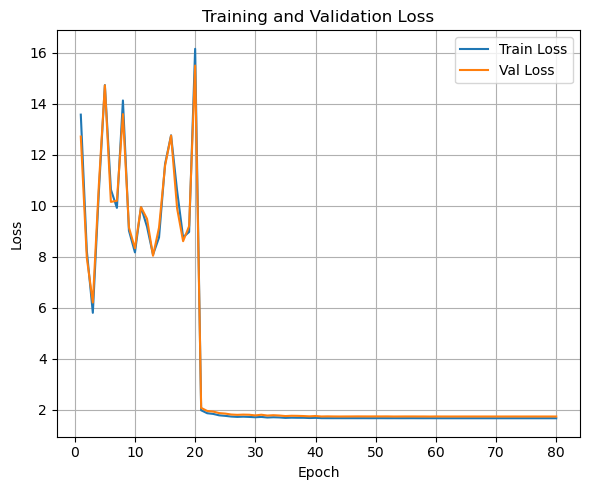

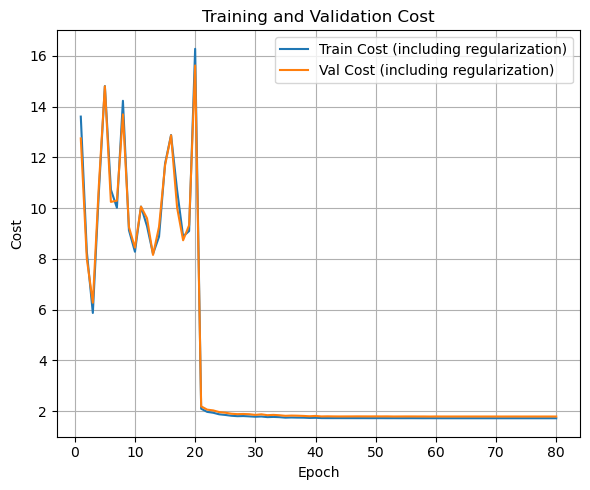

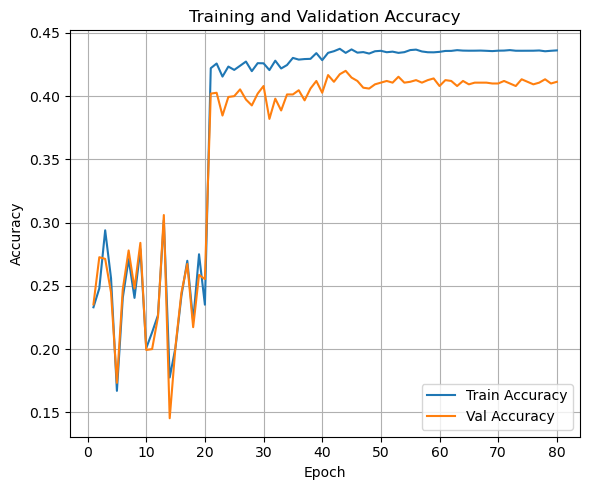

In [6]:
optimizer.plot_training_progress()

In [7]:
# test the model on the test set
X_test, Y_test, y_test = load_batch("test_batch")
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.4232


In [8]:
Y_pred = optimizer.predict(X_test)
N = Y_pred.shape[1]
gt_probs = Y_pred[y_test, np.arange(N)]
y_pred = np.argmax(Y_pred, axis=0)
correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]
probs_correct = gt_probs[correct_idx]
probs_incorrect = gt_probs[incorrect_idx]

In [9]:
probs_correct[0]

np.float64(0.4035655599706236)

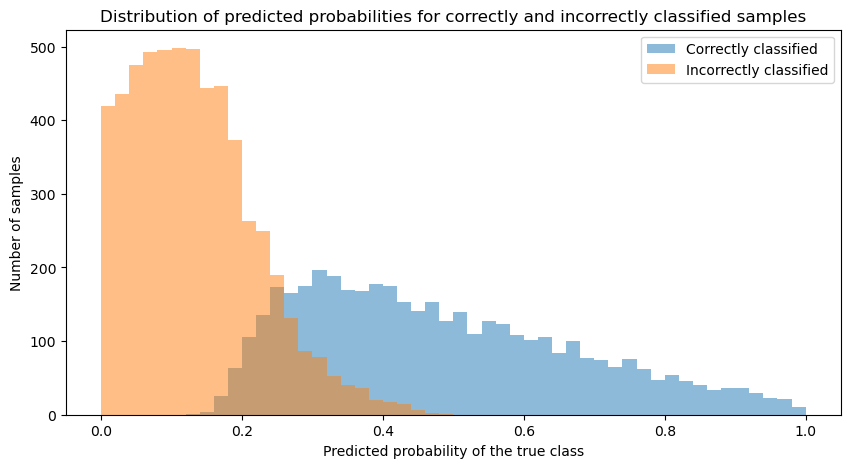

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(probs_correct, bins=50,range=(0,1), alpha=0.5, label='Correctly classified')
plt.hist(probs_incorrect, bins=50, range=(0,1), alpha=0.5, label='Incorrectly classified')
plt.xlabel('Predicted probability of the true class')
plt.ylabel('Number of samples')
plt.legend()
plt.title('Distribution of predicted probabilities for correctly and incorrectly classified samples')
plt.show()

## Part 2 - K-binary CE loss

In [ ]:
from nodes import KBinaryCELoss
model = Model(32*32*3, 10)
optimizer = Optimizer(model, KBinaryCELoss(), lr=1, reg=0.0001, vertical_flip_prob=0.5)
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=80, batch_size=20, decaying_lr_epochs=20, decay_factor=10, print_every=5)


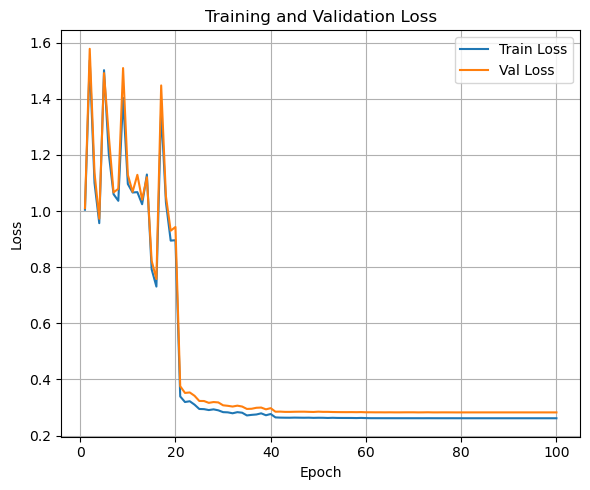

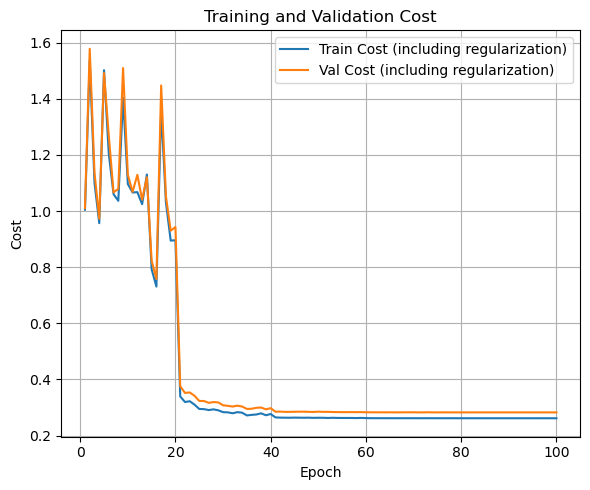

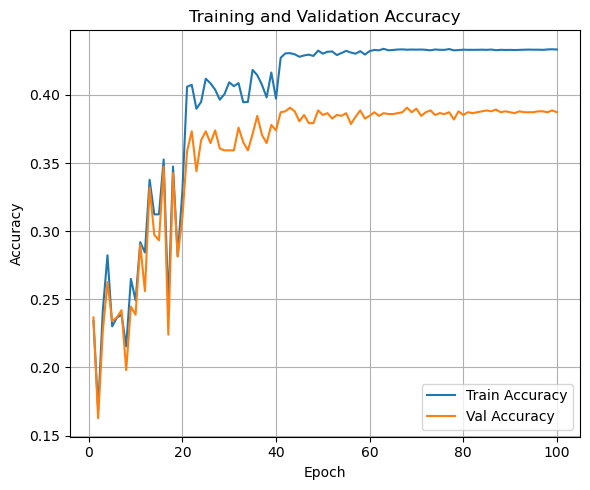

In [23]:
optimizer.plot_training_progress()

In [24]:
print("test accuracy: ", optimizer.compute_accuracy(X_test, y_test))

test accuracy:  0.3857


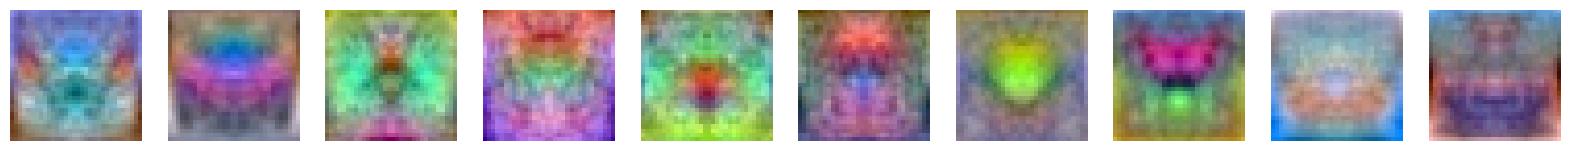

In [19]:
# interesting to see how the nonlinearity affects the learned weights
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')

### Histogram of the probability for the ground truth classes
In this section, we plot a histogram of the probabilities of correctly classified classes, and the histogram of probabilities for incorrectly classified classes for each ground truth label. 

#### For sigmoid

In [20]:
Y_pred = optimizer.predict(X_test)
N = Y_pred.shape[1]
gt_probs = Y_pred[y_test, np.arange(N)]
y_pred = np.argmax(Y_pred, axis=0)
correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]
probs_correct = gt_probs[correct_idx]
probs_incorrect = gt_probs[incorrect_idx]

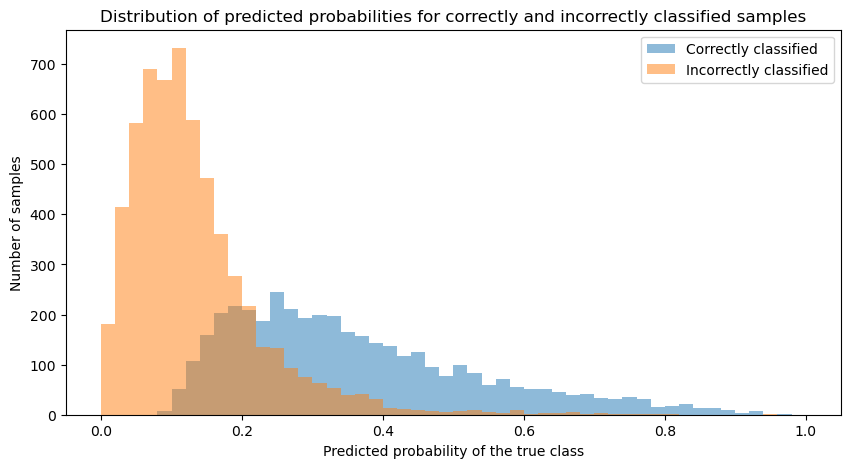

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(probs_correct, bins=50,range=(0,1), alpha=0.5, label='Correctly classified')
plt.hist(probs_incorrect, bins=50, range=(0,1), alpha=0.5, label='Incorrectly classified')
plt.xlabel('Predicted probability of the true class')
plt.ylabel('Number of samples')
plt.legend()
plt.title('Distribution of predicted probabilities for correctly and incorrectly classified samples')
plt.show()